<a href="https://colab.research.google.com/github/kaleidos48-design/Admission_PredictorML/blob/main/Admission_PredictorML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Admission Chance Prediction Using Machine Learning**
## **Introduction**

Predicting a student's chance of admission to a university is an important application of machine learning in the education sector. Admission decisions are influenced by several factors such as GRE score, TOEFL score, university rating, Statement of Purpose (SOP), Letter of Recommendation (LOR), CGPA, and research experience.

This project aims to develop a machine learning model that predicts a student's probability of admission based on these academic and profile-related features.

## **Objectives**


*   Analyze the admission dataset.

*   Perform Exploratory Data Analysis (EDA)

*   Build machine learning regression models to predict the chance of admission.
*   Compare model performance


*   Evaluate the models using appropriate regression metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score.





In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files

uploaded = files.upload()


Saving Admission_dataset.csv to Admission_dataset.csv


In [3]:
df = pd.read_csv("Admission_dataset.csv")

In [4]:
print("Imported Successfully!")
print(df.shape)

Imported Successfully!
(400, 9)


In [5]:
df.head()

,Serial No,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No          400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4    SOP               400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [7]:
df.describe()

,Serial No,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


In [8]:
df.isnull().sum()

,0
Serial No,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


# **Initial Observations**




*   Dataset contains 400 student records.

*   Total features = 9 (including the Serial No column).

*   Target variable = Chance of Admit.

*   The dataset includes academic factors such as GRE Score, TOEFL Score, University Rating, SOP, LOR, CGPA, and Research Experience.



*   Serial No is a unique identifier and will not be used for model training.



*   No missing values were found in the dataset.


*   The dataset is clean and ready for EDA.




# **Exploratory Data Analysis (EDA)**
In this section, we explore the dataset to understand the distribution of transactions and identify patterns related to fraudulent activities.

In [9]:
df['Chance of Admit '].describe()

,Chance of Admit
count,400.000000
mean,0.724350
std,0.142609
min,0.340000
25%,0.640000
50%,0.730000
75%,0.830000
max,0.970000


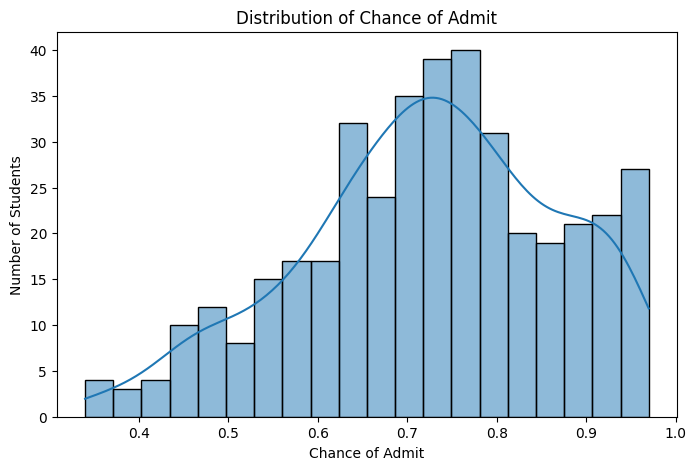

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df['Chance of Admit '], bins=20, kde=True)

plt.title('Distribution of Chance of Admit')
plt.xlabel('Chance of Admit')
plt.ylabel('Number of Students')

plt.show()

# **Observation**


*   The target variable Chance of Admit ranges approximately from 0.34 to 0.97.

*   The distribution of admission chances appears to be reasonably balanced, with most students having a moderate to high probability of admission.







In [11]:
min_chance = df['Chance of Admit '].min()
max_chance = df['Chance of Admit '].max()
avg_chance = df['Chance of Admit '].mean()

print("Minimum Chance of Admit :", round(min_chance, 2))
print("Maximum Chance of Admit :", round(max_chance, 2))
print("Average Chance of Admit :", round(avg_chance, 2))

Minimum Chance of Admit : 0.34
Maximum Chance of Admit : 0.97
Average Chance of Admit : 0.72


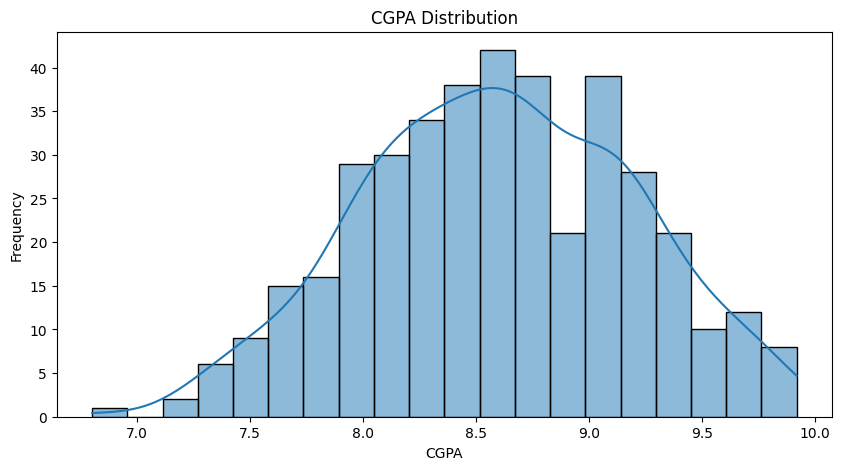

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(df['CGPA'], bins=20, kde=True)

plt.title('CGPA Distribution')
plt.xlabel('CGPA')
plt.ylabel('Frequency')

plt.show()

# **Observation**

*   Most students have a CGPA between 8.0 and 9.5.

*   Only a small number of students have a very low or very high CGPA.










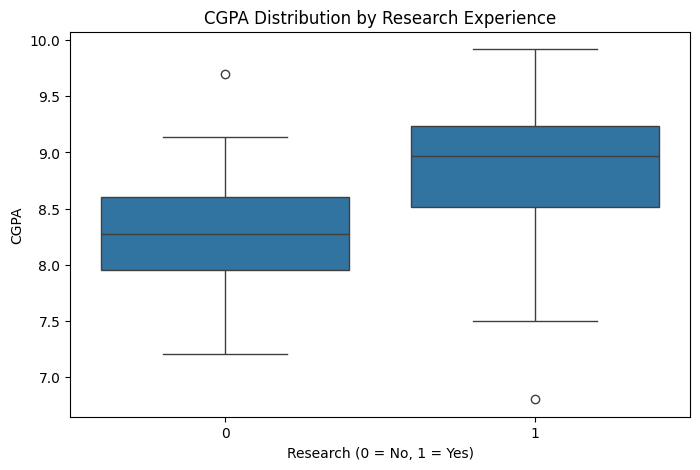

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Research', y='CGPA', data=df)

plt.title('CGPA Distribution by Research Experience')
plt.xlabel('Research (0 = No, 1 = Yes)')
plt.ylabel('CGPA')

plt.show()

In [14]:
df.groupby('Research')['Chance of Admit '].describe()

,count,mean,std,min,25%,50%,75%,max
Research,,,,,,,,
0,181.0,0.637680,0.113784,0.34,0.57,0.65,0.72,0.89
1,219.0,0.795982,0.123051,0.36,0.73,0.80,0.90,0.97


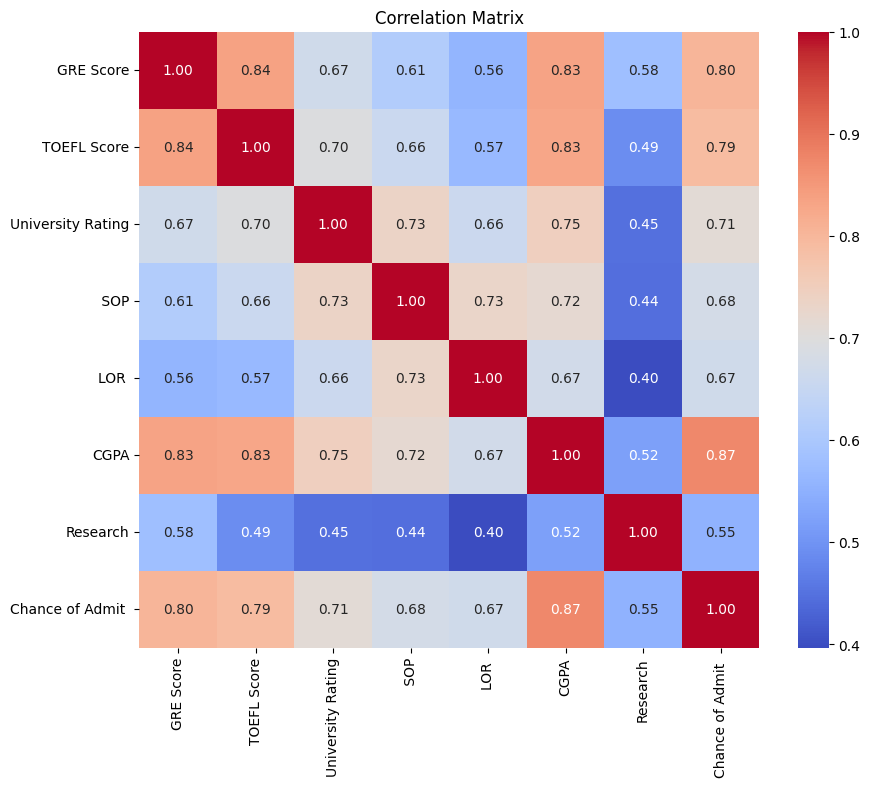

In [15]:
corr_matrix = df.drop('Serial No', axis=1).corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

# **Key Findings**


*   The dataset contains 400 student records with academic and profile-related features.

*   No missing values are present, making the dataset clean and ready for machine learning.

*   CGPA, GRE Score, and TOEFL Score show strong positive relationships with the Chance of Admit.

*   Features such as University Rating, SOP, LOR, and Research Experience also contribute to predicting admission chances.



*   The correlation analysis indicates that the selected features are useful for building accurate regression models to predict students' chances of admission.






In [16]:
df = df.drop('Serial No', axis=1)

df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [17]:
X = df.drop('Chance of Admit ', axis=1)
y = df['Chance of Admit ']

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [20]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (400, 7)
Shape of y: (400,)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (320, 7)
Testing Features  : (80, 7)
Training Labels   : (320,)
Testing Labels    : (80,)


# **Data Preprocessing**

To prepare the dataset for machine learning, the Serial No column was removed because it is only a unique identifier and does not contribute to predicting admission chances.

The dataset was then divided into features (X) and the target variable (y), where Chance of Admit was selected as the target.

Next, all input features were standardized using StandardScaler to ensure that they are on a similar scale. This helps improve the performance of many machine learning algorithms.

Finally, the dataset was split into training (80%) and testing (20%) sets using the train_test_split() function. The training set is used to train the regression model, while the testing set is used to evaluate its performance on unseen data.

# **Linear Regression Model**

Linear Regression is a supervised machine learning algorithm used for regression problems, where the target variable is continuous.

In this project, Linear Regression is used to predict a student's Chance of Admit based on the following features:


Research Experience

*   GRE Score

*   TOEFL Score


*   University Rating

*   Statement of Purpose (SOP)



*   Letter of Recommendation (LOR)



*   CGPA






In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 4))
print("Mean Squared Error (MSE):", round(mse, 4))
print("Root Mean Squared Error (RMSE):", round(rmse, 4))
print("R² Score:", round(r2, 4))

Mean Absolute Error (MAE): 0.048
Mean Squared Error (MSE): 0.0046
Root Mean Squared Error (RMSE): 0.0679
R² Score: 0.8212


In [23]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results.head(10)

,Actual,Predicted
209,0.68,0.651174
280,0.68,0.723687
33,0.90,0.935368
210,0.79,0.821643
93,0.44,0.581587
84,0.94,0.928630
329,0.43,0.526824
94,0.36,0.543090
266,0.72,0.659406
126,0.85,0.838349


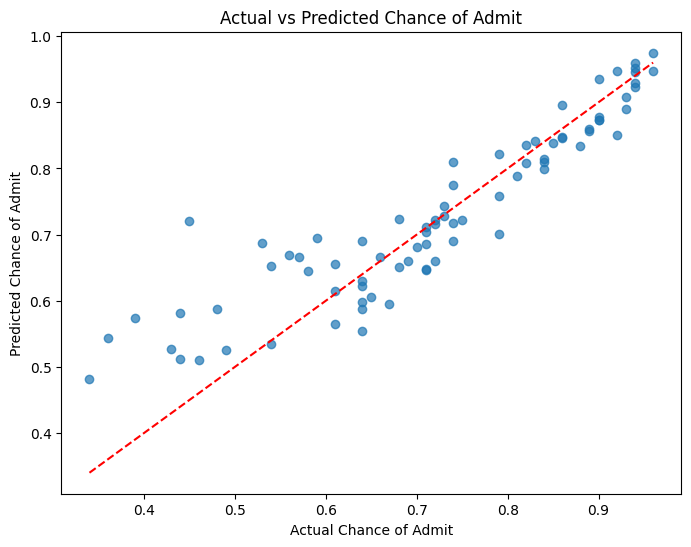

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.title('Actual vs Predicted Chance of Admit')
plt.xlabel('Actual Chance of Admit')
plt.ylabel('Predicted Chance of Admit')

plt.show()

In [25]:
print("Model Performance : ")


print("\nMean Absolute Error (MAE):", round(mae, 4))
print("Mean Squared Error (MSE):", round(mse, 4))
print("Root Mean Squared Error (RMSE):", round(rmse, 4))
print("R² Score:", round(r2, 4))

Model Performance : 

Mean Absolute Error (MAE): 0.048
Mean Squared Error (MSE): 0.0046
Root Mean Squared Error (RMSE): 0.0679
R² Score: 0.8212


# **Model Evaluation**

The Linear Regression model was evaluated using regression metrics.


*   Mean Absolute Error (MAE) measures the average prediction error.


*   Mean Squared Error (MSE) gives higher weight to larger prediction errors.


*   Root Mean Squared Error (RMSE) represents the prediction error in the same units as the target variable.

*   R² Score indicates how well the model explains the variation in the admission chances. A value closer to 1 represents better model performance.






These metrics provide a comprehensive evaluation of the regression model's predictive accuracy.

# **Decision Tree Regressor**

Decision Tree Regression is a supervised machine learning algorithm used for predicting continuous numerical values.

It works by recursively splitting the dataset into smaller groups based on feature values and making predictions based on the average value within each group.





Decision Tree Regressor Performance

MAE : 0.0661
MSE : 0.0095
RMSE: 0.0973
R² Score: 0.6331


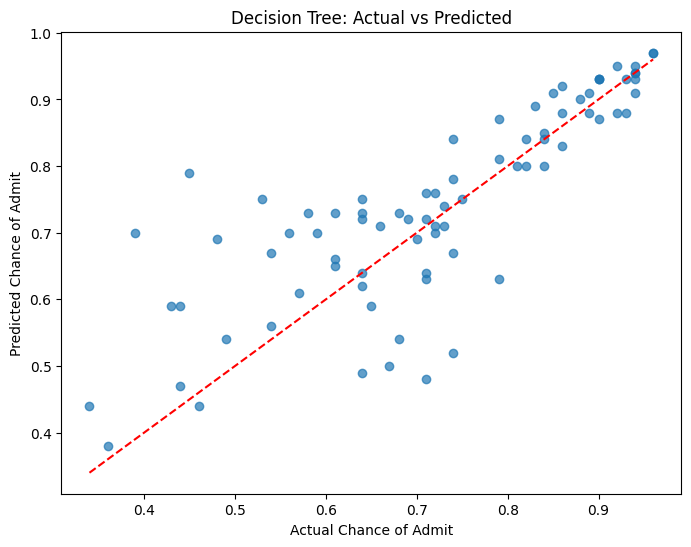

In [26]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Regressor Performance")
print("\nMAE :", round(dt_mae, 4))
print("MSE :", round(dt_mse, 4))
print("RMSE:", round(dt_rmse, 4))
print("R² Score:", round(dt_r2, 4))

plt.figure(figsize=(8,6))

plt.scatter(y_test, dt_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.title("Decision Tree: Actual vs Predicted")
plt.xlabel("Actual Chance of Admit")
plt.ylabel("Predicted Chance of Admit")

plt.show()

# **Decision Tree Regressor Analysis**

The Decision Tree Regressor was trained to predict students' chances of admission based on their academic performance and research experience.

Results

*   Mean Absolute Error (MAE): 0.0661

*   Mean Squared Error (MSE): 0.0095
*   Root Mean Squared Error (RMSE): 0.0973



*   R² Score: 0.6331






The model successfully learned the relationship between the input features and the target variable. It was able to capture non-linear patterns in the data, making it suitable for predicting admission chances.

The model's performance can be compared with Linear Regression using the evaluation metrics. A higher R² Score and lower MAE and RMSE indicate better predictive performance.

## **Random Forest Regressor**

Random Forest Regressor Performance

MAE : 0.0493
MSE : 0.0049
RMSE: 0.0703
R² Score: 0.8088


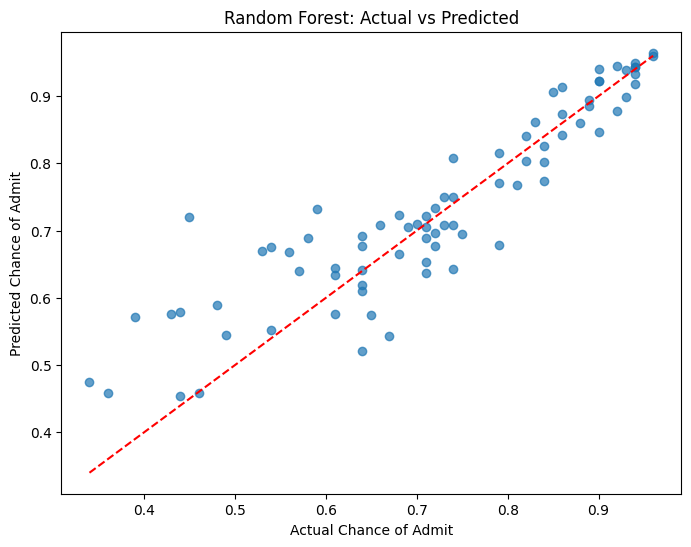

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regressor Performance")
print("\nMAE :", round(rf_mae, 4))
print("MSE :", round(rf_mse, 4))
print("RMSE:", round(rf_rmse, 4))
print("R² Score:", round(rf_r2, 4))

plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual Chance of Admit")
plt.ylabel("Predicted Chance of Admit")

plt.show()

# **Random Forest Regressor Analysis**

The Random Forest Regressor achieved strong performance in predicting students' chances of admission by combining the predictions of multiple decision trees. This ensemble approach improves prediction accuracy and reduces the risk of overfitting compared to a single Decision Tree.

Results

*   Mean Absolute Error (MAE): 0.0493


*   Mean Squared Error (MSE): 0.0049

*   Root Mean Squared Error (RMSE): 0.0703



*   R² Score: 0.8088




The Random Forest Regressor effectively captured the relationships between the input features and the target variable. Its performance was evaluated using regression metrics and compared with the other regression models.

Based on the evaluation results, the model with the highest R² Score and the lowest MAE and RMSE was selected as the final model for predicting students' chances of admission.

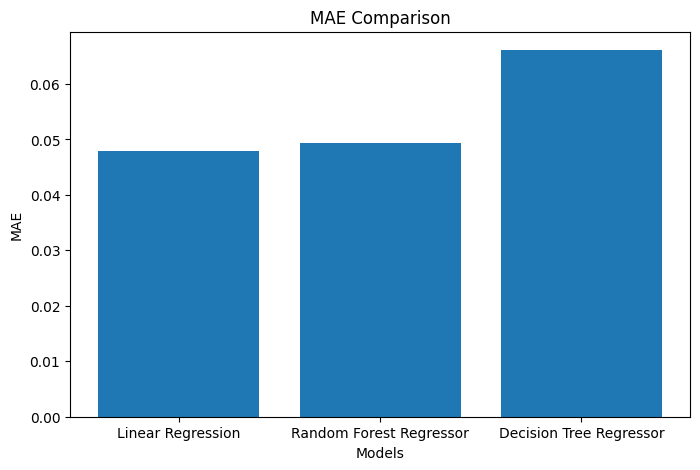

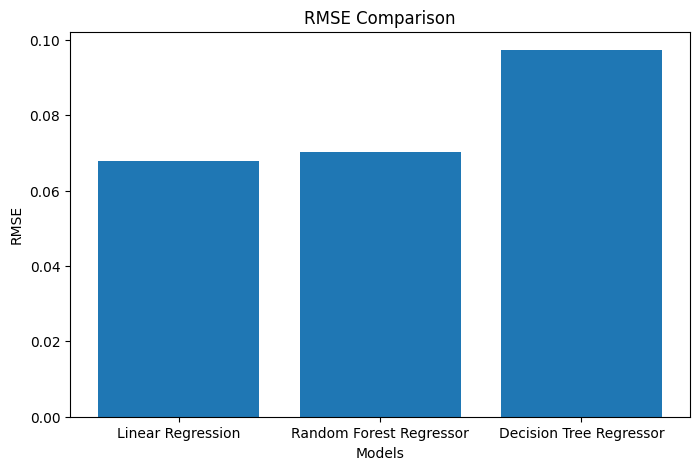

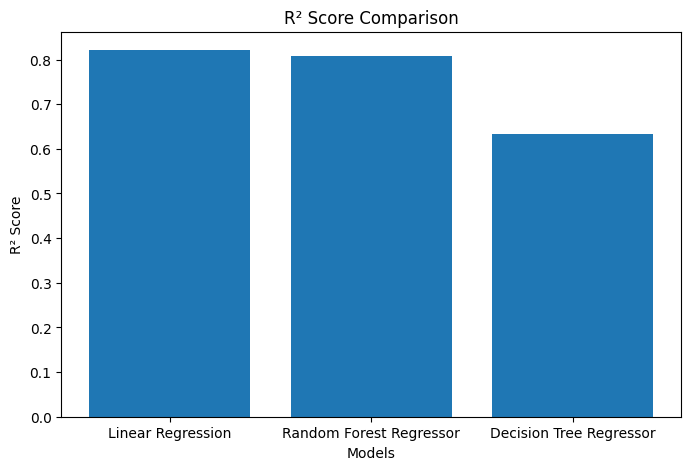

In [28]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree Regressor',
        'Random Forest Regressor'
    ],
    'MAE': [
        mae,
        dt_mae,
        rf_mae
    ],
    'RMSE': [
        rmse,
        dt_rmse,
        rf_rmse
    ],
    'R² Score': [
        r2,
        dt_r2,
        rf_r2
    ]
})

comparison

comparison = comparison.sort_values(
    by='R² Score',
    ascending=False
)

comparison

plt.figure(figsize=(8,5))

plt.bar(comparison['Model'], comparison['MAE'])

plt.title('MAE Comparison')
plt.xlabel('Models')
plt.ylabel('MAE')

plt.show()

plt.figure(figsize=(8,5))

plt.bar(comparison['Model'], comparison['RMSE'])

plt.title('RMSE Comparison')
plt.xlabel('Models')
plt.ylabel('RMSE')

plt.show()

plt.figure(figsize=(8,5))

plt.bar(comparison['Model'], comparison['R² Score'])

plt.title('R² Score Comparison')
plt.xlabel('Models')
plt.ylabel('R² Score')

plt.show()

In [29]:
best_model = comparison.iloc[0]

print("Best Performing Model")
print("\nModel :", best_model['Model'])
print("R² Score :", round(best_model['R² Score'], 4))
print("RMSE :", round(best_model['RMSE'], 4))
print("MAE :", round(best_model['MAE'], 4))

Best Performing Model

Model : Linear Regression
R² Score : 0.8212
RMSE : 0.0679
MAE : 0.048


### **Feature Importance**

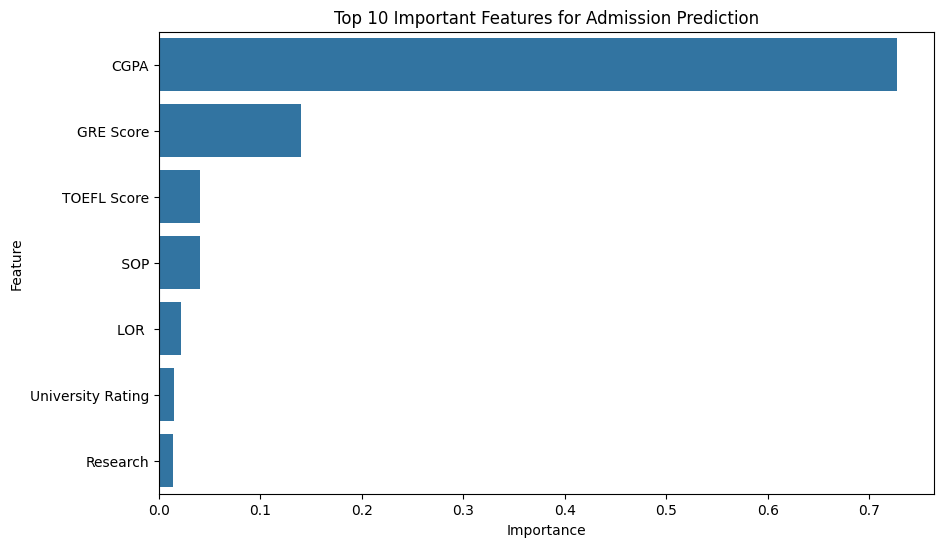

In [30]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 10 Important Features for Admission Prediction")

plt.show()

#Feature Importance Analysis

The Random Forest Regressor ranks the input features based on their contribution to predicting students' chances of admission.



From the analysis, academic factors such as **CGPA**, **GRE Score**, and **TOEFL Score** are expected to be among the most influential features, while the remaining features also contribute to the model's overall predictive performance.


In [31]:
def predict_admission(student_data):
    """
    Predict the chance of admission for a new student.
    """

    student_data_scaled = scaler.transform([student_data])

    prediction = rf_model.predict(student_data_scaled)

    return prediction[0]

In [32]:
new_student = [
    325,
    112,
    4,
    4.5,
    4.5,
    9.2,
    1
]

prediction = predict_admission(new_student)

print(f"Predicted Chance of Admit: {prediction:.2f}")

Predicted Chance of Admit: 0.88


In [33]:
import joblib

joblib.dump(
    rf_model,
    'admission_chance_prediction_model.pkl'
)

joblib.dump(
    scaler,
    'scaler.pkl'
)

loaded_model = joblib.load(
    'admission_chance_prediction_model.pkl'
)

loaded_scaler = joblib.load(
    'scaler.pkl'
)

# Conclusion

In this project, machine learning regression techniques were used to predict students' chances of admission based on their academic performance and research experience.

Three regression algorithms were implemented and evaluated:

* Linear Regression
* Decision Tree Regressor
* Random Forest Regressor

The models were evaluated using **Mean Absolute Error (MAE)**, **Mean Squared Error (MSE)**, **Root Mean Squared Error (RMSE)**, and **R² Score**. Their performances were compared to identify the most suitable model for predicting admission chances.

Among all the models, the one with the **highest R² Score** and the **lowest MAE and RMSE** was selected as the best-performing model. The comparison demonstrated that evaluating multiple regression algorithms helps in selecting the most accurate and reliable predictive model.

This project shows that machine learning can effectively predict students' admission chances using academic features such as **GRE Score, TOEFL Score, University Rating, SOP, LOR, CGPA, and Research Experience**. Such predictive models can assist students in estimating their admission prospects and support educational institutions in understanding the factors that influence admission decisions.


## Project Outcome

A machine learning-based admission chance prediction system was successfully developed using multiple regression algorithms. The project included data preprocessing, exploratory data analysis, feature scaling, model training, performance evaluation, and model comparison.

The trained models were evaluated using **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and **R² Score** to identify the most accurate model for predicting students' chances of admission.

The final model can estimate a student's probability of admission based on academic and profile-related features such as **GRE Score, TOEFL Score, University Rating, SOP, LOR, CGPA, and Research Experience**.

Overall, this project demonstrates the practical application of machine learning in educational data analysis and shows how predictive models can assist students in evaluating their admission prospects and support data-driven decision-making in higher education.
